# Perceptron

In [86]:
import numpy as np
from sklearn.datasets import load_iris
from sklearn.linear_model import Perceptron

iris = load_iris()
X = iris.data[:, (2, 3)] # petal length, petal width
y = (iris.target == 0).astype(np.int64) # Iris Setosa?

per_clf = Perceptron()
per_clf.fit(X, y)

Perceptron()

In [87]:
y_pred = per_clf.predict([[2, 0.5]])
y_pred

array([0], dtype=int64)

## MLP

In [52]:
import tensorflow as tf
from tensorflow import keras

In [53]:
tf.__version__

'2.11.0'

In [54]:
keras.__version__

'2.11.0'

## Building an Image Classifier Using the Sequential API

In [55]:
fashion_mnist = keras.datasets.fashion_mnist
(X_train_full, y_train_full), (X_test, y_test) = fashion_mnist.load_data()

In [56]:
X_train_full.shape

(60000, 28, 28)

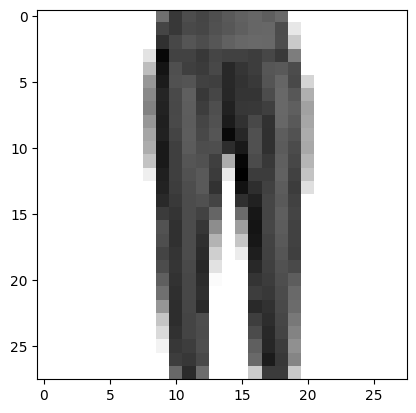

In [57]:
import matplotlib.pyplot as plt
import numpy as np

plt.imshow(X_train_full[7832], cmap="binary")

In [58]:
X_train_full.dtype

dtype('uint8')

scale down the data

In [59]:
X_valid, X_train = X_train_full[:5000] / 255.0, X_train_full[5000:] / 255.0
y_valid, y_train = y_train_full[:5000], y_train_full[5000:]

In [60]:
class_names = ["T-shirt/top", "Trouser", "Pullover", "Dress", "Coat", "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"]

In [61]:
class_names[y_train[0]]

'Coat'

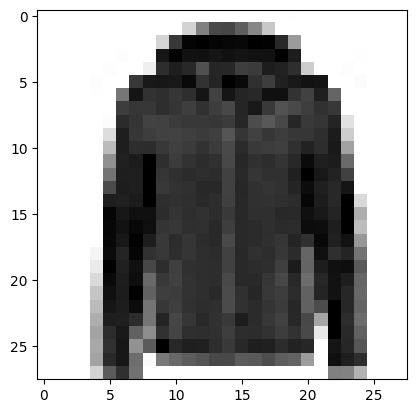

In [62]:
import matplotlib.pyplot as plt
plt.imshow(X_train[0], cmap="binary")

### Creating the model using the Sequential AP

In [63]:
model = keras.models.Sequential()
model.add(keras.layers.Flatten(input_shape=[28, 28]))
model.add(keras.layers.Dense(300, activation="relu"))
model.add(keras.layers.Dense(100, activation="relu"))
model.add(keras.layers.Dense(10, activation="softmax"))

In [64]:
model.summary()

Model: "sequential_2"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 flatten_1 (Flatten)         (None, 784)               0         
                                                                 
 dense_18 (Dense)            (None, 300)               235500    
                                                                 
 dense_19 (Dense)            (None, 100)               30100     
                                                                 
 dense_20 (Dense)            (None, 10)                1010      
                                                                 
Total params: 266,610
Trainable params: 266,610
Non-trainable params: 0
_________________________________________________________________


In [65]:
model.layers

we can name layers

In [66]:
hidden1 = model.layers[1]
hidden1.name

'dense_18'

we can access all the parameters of a layer using get_weights() and set_weights()

In [67]:
weights, biases = hidden1.get_weights()

In [68]:
weights

array([[ 0.05098386,  0.00366945, -0.06811653, ..., -0.04670969,
        -0.03050136, -0.01198173],
       [-0.03505516, -0.03341418, -0.06544568, ..., -0.00047752,
        -0.02156159,  0.02144757],
       [ 0.01637257, -0.01472025,  0.02956049, ...,  0.05749889,
        -0.07426853, -0.00385715],
       ...,
       [-0.03005573, -0.01767419,  0.0737969 , ...,  0.01695432,
         0.0681594 ,  0.01644485],
       [ 0.04490031, -0.06402344, -0.04355025, ...,  0.01975399,
        -0.00162747,  0.03685874],
       [ 0.03032098,  0.04543837, -0.05031716, ...,  0.02662466,
        -0.05922625,  0.01330307]], dtype=float32)

In [69]:
biases

array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0.

#### Compiling the model

After a model is created, you must call its compile() method to specify the loss function and the optimizer to use.

In [70]:
model.compile(loss="sparse_categorical_crossentropy", optimizer="sgd",metrics=["accuracy"])

In [71]:
history = model.fit(X_train, y_train, epochs=30, validation_data=(X_valid, y_valid))

Epoch 1/30
1719/1719 [==============================] - 7s 4ms/step - loss: 0.7140 - accuracy: 0.7653 - val_loss: 0.4999 - val_accuracy: 0.8320
Epoch 2/30
1719/1719 [==============================] - 6s 3ms/step - loss: 0.4865 - accuracy: 0.8306 - val_loss: 0.4484 - val_accuracy: 0.8486
Epoch 3/30
1719/1719 [==============================] - 6s 4ms/step - loss: 0.4423 - accuracy: 0.8455 - val_loss: 0.4123 - val_accuracy: 0.8608
Epoch 4/30
1719/1719 [==============================] - 6s 3ms/step - loss: 0.4152 - accuracy: 0.8538 - val_loss: 0.4039 - val_accuracy: 0.8610
Epoch 5/30
1719/1719 [==============================] - 6s 3ms/step - loss: 0.3957 - accuracy: 0.8607 - val_loss: 0.3785 - val_accuracy: 0.8670
Epoch 6/30
1719/1719 [==============================] - 5s 3ms/step - loss: 0.3798 - accuracy: 0.8663 - val_loss: 0.3857 - val_accuracy: 0.8688
Epoch 7/30
1719/1719 [==============================] - 5s 3ms/step - loss: 0.3666 - accuracy: 0.8705 - val_loss: 0.3675 - val_accuracy:

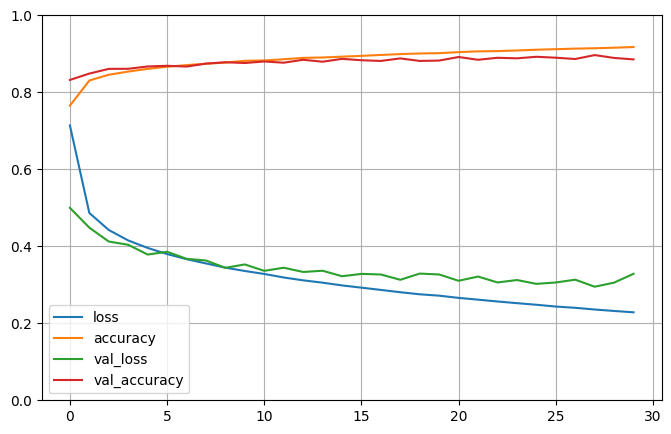

In [72]:
import pandas as pd
import matplotlib.pyplot as plt
pd.DataFrame(history.history).plot(figsize=(8, 5))
plt.grid(True)
plt.gca().set_ylim(0, 1) # set the vertical range to [0-1]
plt.show()

evaluating on the test set

In [73]:
model.evaluate(X_test, y_test)

313/313 [==============================] - 1s 2ms/step - loss: 84.4527 - accuracy: 0.8184


[84.45269775390625, 0.8184000253677368]

### Using the model to make predictions

In [74]:
X_new = X_test[:3]
y_proba = model.predict(X_new)
y_proba.round(2)

1/1 [==============================] - 0s 60ms/step


array([[0., 0., 0., 0., 0., 0., 0., 0., 0., 1.],
       [0., 0., 1., 0., 0., 0., 0., 0., 0., 0.],
       [0., 1., 0., 0., 0., 0., 0., 0., 0., 0.]], dtype=float32)

## Building a Regression MLP Using the Sequential API

In [4]:
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
housing = fetch_california_housing()
X_train_full, X_test, y_train_full, y_test = train_test_split(housing.data, housing.target)
X_train, X_valid, y_train, y_valid = train_test_split(X_train_full, y_train_full)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_valid = scaler.transform(X_valid)
X_test = scaler.transform(X_test)

In [113]:
model = keras.models.Sequential([
            keras.layers.Dense(30, activation="relu", input_shape=X_train.shape[1:]),
            keras.layers.Dense(1)
        ])
model.compile(loss="mean_squared_error", optimizer="sgd")
history = model.fit(X_train, y_train, epochs=20,
validation_data=(X_valid, y_valid))

Epoch 1/20
363/363 [==============================] - 2s 3ms/step - loss: 1.1393 - val_loss: 0.5713
Epoch 2/20
363/363 [==============================] - 1s 3ms/step - loss: 0.5518 - val_loss: 0.4897
Epoch 3/20
363/363 [==============================] - 1s 3ms/step - loss: 0.4847 - val_loss: 0.4636
Epoch 4/20
363/363 [==============================] - 1s 2ms/step - loss: 0.4630 - val_loss: 0.4349
Epoch 5/20
363/363 [==============================] - 1s 2ms/step - loss: 0.4448 - val_loss: 0.4336
Epoch 6/20
363/363 [==============================] - 1s 3ms/step - loss: 0.4286 - val_loss: 0.4161
Epoch 7/20
363/363 [==============================] - 1s 3ms/step - loss: 0.4280 - val_loss: 0.4176
Epoch 8/20
363/363 [==============================] - 1s 3ms/step - loss: 0.4155 - val_loss: 0.4086
Epoch 9/20
363/363 [==============================] - 1s 2ms/step - loss: 0.4082 - val_loss: 0.4040
Epoch 10/20
363/363 [==============================] - 1s 4ms/step - loss: 0.4026 - val_loss: 0.3963

In [70]:
mse_test = model.evaluate(X_test, y_test)
X_new = X_test[:3]
y_pred = model.predict(X_new)

1/1 [==============================] - 0s 117ms/step


In [78]:
y_pred

array([[2.4749289],
       [1.945194 ],
       [1.496773 ]], dtype=float32)

## Building Complex Models Using the Functional API

In [103]:
input_ = keras.layers.Input(shape=X_train.shape[1:])
hidden1 = keras.layers.Dense(30, activation="relu")(input_)
hidden2 = keras.layers.Dense(30, activation="relu")(hidden1)
concat = keras.layers.Concatenate()([input_, hidden2])
output = keras.layers.Dense(1)(concat)
model = keras.Model(inputs=[input_], outputs=[output])

using multiple inputs if we want some features to pass through wide path and others through deep path

In [104]:
input_A = keras.layers.Input(shape=[5], name="wide_input")
input_B = keras.layers.Input(shape=[6], name="deep_input")
hidden1 = keras.layers.Dense(30, activation="relu")(input_B)
hidden2 = keras.layers.Dense(30, activation="relu")(hidden1)
concat = keras.layers.concatenate([input_A, hidden2])
output = keras.layers.Dense(1, name="output")(concat)
model = keras.Model(inputs=[input_A, input_B], outputs=[output])

In [105]:
model.compile(loss="mse", optimizer="sgd")
X_train_A, X_train_B = X_train[:, :5], X_train[:, 2:]
X_valid_A, X_valid_B = X_valid[:, :5], X_valid[:, 2:]
X_test_A, X_test_B = X_test[:, :5], X_test[:, 2:]
X_new_A, X_new_B = X_test_A[:3], X_test_B[:3]
history = model.fit((X_train_A, X_train_B), y_train, epochs=20,
validation_data=((X_valid_A, X_valid_B), y_valid))
mse_test = model.evaluate((X_test_A, X_test_B), y_test)
y_pred = model.predict((X_new_A, X_new_B))

Epoch 1/20
363/363 [==============================] - 3s 4ms/step - loss: 0.8219 - val_loss: 0.7635
Epoch 2/20
363/363 [==============================] - 1s 3ms/step - loss: nan - val_loss: nan
Epoch 3/20
363/363 [==============================] - 2s 5ms/step - loss: nan - val_loss: nan
Epoch 4/20
363/363 [==============================] - 2s 5ms/step - loss: nan - val_loss: nan
Epoch 5/20
363/363 [==============================] - 1s 3ms/step - loss: nan - val_loss: nan
Epoch 6/20
363/363 [==============================] - 1s 2ms/step - loss: nan - val_loss: nan
Epoch 7/20
363/363 [==============================] - 1s 2ms/step - loss: nan - val_loss: nan
Epoch 8/20
363/363 [==============================] - 1s 2ms/step - loss: nan - val_loss: nan
Epoch 9/20
363/363 [==============================] - 1s 3ms/step - loss: nan - val_loss: nan
Epoch 10/20
363/363 [==============================] - 1s 4ms/step - loss: nan - val_loss: nan
Epoch 11/20
363/363 [==============================] 

we can add auxiliary output for regularization

In [102]:
output = keras.layers.Dense(1)(concat)
aux_output = keras.layers.Dense(1)(hidden2)
model = keras.models.Model(inputs=[input_A, input_B], outputs=[output, aux_output])

by default keras will compute all losses of output layers and add them together. But, we can set the weight loss for each output layers

In [83]:
model.compile(loss=["mse", "mse"], loss_weights=[0.9, 0.1], optimizer="sgd")

In [84]:
history = model.fit(
[X_train_A, X_train_B], [y_train, y_train], epochs=20, validation_data=([X_valid_A, X_valid_B], [y_valid, y_valid]))

Epoch 1/20
363/363 [==============================] - 2s 3ms/step - loss: 1.3605 - dense_28_loss: 1.1267 - dense_29_loss: 3.4644 - val_loss: 0.7910 - val_dense_28_loss: 0.6119 - val_dense_29_loss: 2.4032
Epoch 2/20
363/363 [==============================] - 1s 2ms/step - loss: 0.7949 - dense_28_loss: 0.6623 - dense_29_loss: 1.9883 - val_loss: 0.7045 - val_dense_28_loss: 0.5972 - val_dense_29_loss: 1.6702
Epoch 3/20
363/363 [==============================] - 1s 2ms/step - loss: 0.7374 - dense_28_loss: 0.6475 - dense_29_loss: 1.5466 - val_loss: 0.6732 - val_dense_28_loss: 0.5880 - val_dense_29_loss: 1.4398
Epoch 4/20
363/363 [==============================] - 1s 2ms/step - loss: 0.7216 - dense_28_loss: 0.6460 - dense_29_loss: 1.4027 - val_loss: 0.6629 - val_dense_28_loss: 0.5847 - val_dense_29_loss: 1.3675
Epoch 5/20
363/363 [==============================] - 1s 2ms/step - loss: 0.7177 - dense_28_loss: 0.6467 - dense_29_loss: 1.3568 - val_loss: 0.6602 - val_dense_28_loss: 0.5838 - val_de

When we evaluate the model, Keras will return the total loss, as well as all the individual losses

In [85]:
total_loss, main_loss, aux_loss = model.evaluate([X_test_A, X_test_B], [y_test, y_test])

162/162 [==============================] - 0s 2ms/step - loss: 0.6684 - dense_28_loss: 0.5951 - dense_29_loss: 1.3282


Similarly, the predict() method will return predictions for each output

In [86]:
y_pred_main, y_pred_aux = model.predict([X_new_A, X_new_B])

1/1 [==============================] - 0s 77ms/step


## Saving and Restoring a Model

In [114]:
model.save("saved_objects/neural_network/my_keras_model.h5")

In [2]:
import keras
model = keras.models.load_model("saved_objects/neural_network/my_keras_model.h5")

## Using Callbacks

The fit() method accepts a callbacks argument that lets you specify a list of objects that Keras will call during training at the start and end of training, at the start and end of each epoch and even before and after processing each batch. 

In [14]:
checkpoint_cb = keras.callbacks.ModelCheckpoint("saved_objects/neural_network/my_keras_model.h5")
history = model.fit(X_train, y_train, epochs=10, callbacks=[checkpoint_cb])

Epoch 1/10
363/363 [==============================] - 1s 3ms/step - loss: 0.3272
Epoch 2/10
363/363 [==============================] - 1s 3ms/step - loss: 0.3190
Epoch 3/10
363/363 [==============================] - 1s 3ms/step - loss: 0.3172
Epoch 4/10
363/363 [==============================] - 1s 3ms/step - loss: 0.3224
Epoch 5/10
363/363 [==============================] - 2s 6ms/step - loss: 0.3241
Epoch 6/10
363/363 [==============================] - 2s 6ms/step - loss: 0.3179
Epoch 7/10
363/363 [==============================] - 1s 3ms/step - loss: 0.3160
Epoch 8/10
363/363 [==============================] - 1s 3ms/step - loss: 0.3160
Epoch 9/10
363/363 [==============================] - 1s 4ms/step - loss: 0.3189
Epoch 10/10
363/363 [==============================] - 1s 3ms/step - loss: 0.3462


Moreover, if you use a validation set during training, you can set save_best_only=True when creating the ModelCheckpoint. In this case, it will only save your model when its performance on the validation set is the best so far. 

This is a simple way to implement early stopping

In [30]:
checkpoint_cb = keras.callbacks.ModelCheckpoint("saved_objects/neural_network/my_keras_model.h5", save_best_only=True)
history = model.fit(X_train, y_train, epochs=10, validation_data=(X_valid, y_valid), callbacks=[checkpoint_cb])
model = keras.models.load_model("saved_objects/neural_network/my_keras_model.h5") # rollback to best model

Epoch 1/10
363/363 [==============================] - 1s 2ms/step - loss: 0.2959 - val_loss: 0.3027
Epoch 2/10
363/363 [==============================] - 1s 3ms/step - loss: 0.2963 - val_loss: 0.3076
Epoch 3/10
363/363 [==============================] - 1s 3ms/step - loss: 0.2963 - val_loss: 0.3079
Epoch 4/10
363/363 [==============================] - 1s 2ms/step - loss: 0.2965 - val_loss: 0.3021
Epoch 5/10
363/363 [==============================] - 1s 2ms/step - loss: 0.2953 - val_loss: 0.3089
Epoch 6/10
363/363 [==============================] - 1s 3ms/step - loss: 0.2971 - val_loss: 0.3030
Epoch 7/10
363/363 [==============================] - 1s 2ms/step - loss: 0.2958 - val_loss: 0.3063
Epoch 8/10
363/363 [==============================] - 1s 2ms/step - loss: 0.2960 - val_loss: 0.3149
Epoch 9/10
363/363 [==============================] - 1s 3ms/step - loss: 0.2962 - val_loss: 0.3023
Epoch 10/10
363/363 [==============================] - 1s 2ms/step - loss: 0.2956 - val_loss: 0.3037

Another way to implement early stopping is to simply use the EarlyStopping callback.

In [29]:
early_stopping_cb = keras.callbacks.EarlyStopping(patience=10, restore_best_weights=True)
history = model.fit(X_train, y_train, epochs=100, validation_data=(X_valid, y_valid), callbacks=[checkpoint_cb, early_stopping_cb])

Epoch 1/100
363/363 [==============================] - 1s 3ms/step - loss: 0.2977 - val_loss: 0.3037
Epoch 2/100
363/363 [==============================] - 1s 2ms/step - loss: 0.2981 - val_loss: 0.2998
Epoch 3/100
363/363 [==============================] - 1s 2ms/step - loss: 0.2962 - val_loss: 0.3094
Epoch 4/100
363/363 [==============================] - 1s 2ms/step - loss: 0.2982 - val_loss: 0.3039
Epoch 5/100
363/363 [==============================] - 1s 2ms/step - loss: 0.2970 - val_loss: 0.3007
Epoch 6/100
363/363 [==============================] - 1s 2ms/step - loss: 0.2991 - val_loss: 0.3037
Epoch 7/100
363/363 [==============================] - 1s 2ms/step - loss: 0.2971 - val_loss: 0.3041
Epoch 8/100
363/363 [==============================] - 1s 2ms/step - loss: 0.3021 - val_loss: 0.3051
Epoch 9/100
363/363 [==============================] - 1s 2ms/step - loss: 0.3030 - val_loss: 0.3080
Epoch 10/100
363/363 [==============================] - 1s 2ms/step - loss: 0.2990 - val_lo

we can define our own callback. For example, the following custom callback will display the ratio between the validation loss and the training loss during training (e.g., to detect overfitting)

In [18]:
class PrintValTrainRatioCallback(keras.callbacks.Callback):
    def on_epoch_end(self, epoch, logs):
        print("\nval/train: {:.2f}".format(logs["val_loss"] / logs["loss"]))

In [21]:
custom_cb = PrintValTrainRatioCallback()
history = model.fit(X_train, y_train, epochs=10, validation_data=(X_valid, y_valid), callbacks=[custom_cb])

Epoch 1/10
359/363 [============================>.] - ETA: 0s - loss: 0.3043
val/train: 1.01
363/363 [==============================] - 1s 4ms/step - loss: 0.3051 - val_loss: 0.3080
Epoch 2/10
362/363 [============================>.] - ETA: 0s - loss: 0.3088
val/train: 1.00
363/363 [==============================] - 1s 3ms/step - loss: 0.3087 - val_loss: 0.3100
Epoch 3/10
344/363 [===========================>..] - ETA: 0s - loss: 0.3060
val/train: 1.02
363/363 [==============================] - 1s 3ms/step - loss: 0.3042 - val_loss: 0.3092
Epoch 4/10
358/363 [============================>.] - ETA: 0s - loss: 0.3060
val/train: 1.01
363/363 [==============================] - 2s 4ms/step - loss: 0.3051 - val_loss: 0.3095
Epoch 5/10
362/363 [============================>.] - ETA: 0s - loss: 0.3092
val/train: 1.01
363/363 [==============================] - 2s 5ms/step - loss: 0.3091 - val_loss: 0.3118
Epoch 6/10
357/363 [============================>.] - ETA: 0s - loss: 0.3054
val/train: 1.

# Visualization Using TensorBoard

In [31]:
import os
import time


root_logdir = os.path.join(os.curdir, "saved_objects/neural_network/my_logs")
def get_run_logdir():
    run_id = time.strftime("run_%Y_%m_%d-%H_%M_%S")
    return os.path.join(root_logdir, run_id)

run_logdir = get_run_logdir()

In [32]:
tensorboard_cb = keras.callbacks.TensorBoard(run_logdir)
history = model.fit(X_train, y_train, epochs=30, validation_data=(X_valid, y_valid), callbacks=[tensorboard_cb])

Epoch 1/30
363/363 [==============================] - 1s 2ms/step - loss: 0.2973 - val_loss: 0.3005
Epoch 2/30
363/363 [==============================] - 1s 2ms/step - loss: 0.2954 - val_loss: 0.3063
Epoch 3/30
363/363 [==============================] - 1s 3ms/step - loss: 0.2966 - val_loss: 0.3092
Epoch 4/30
363/363 [==============================] - 1s 2ms/step - loss: 0.3015 - val_loss: 0.3000
Epoch 5/30
363/363 [==============================] - 1s 2ms/step - loss: 0.2961 - val_loss: 0.3034
Epoch 6/30
363/363 [==============================] - 1s 2ms/step - loss: 0.2957 - val_loss: 0.3044
Epoch 7/30
363/363 [==============================] - 1s 2ms/step - loss: 0.2955 - val_loss: 0.3069
Epoch 8/30
363/363 [==============================] - 1s 2ms/step - loss: 0.2958 - val_loss: 0.3048
Epoch 9/30
363/363 [==============================] - 1s 2ms/step - loss: 0.2953 - val_loss: 0.3015
Epoch 10/30
363/363 [==============================] - 1s 2ms/step - loss: 0.2961 - val_loss: 0.3020

# Fine-Tuning Neural Network Hyperparameters

In [56]:
def build_model(n_hidden=1, n_neurons=30, learning_rate=3e-3, input_shape=[8]):
    model = keras.models.Sequential()
    options = {"input_shape": input_shape}
    for layer in range(n_hidden):
        model.add(keras.layers.Dense(n_neurons, activation="relu", **options))
        options = {}
    model.add(keras.layers.Dense(1, **options))
    optimizer = keras.optimizers.SGD(learning_rate)
    model.compile(loss="mse", optimizer=optimizer)
    return model

In [55]:
keras.backend.clear_session()

In [ ]:
import keras.wrappers.scikit_learn
keras_reg = keras.wrappers.scikit_learn.KerasRegressor(build_model)

In [71]:
keras_reg.fit(X_train, y_train, epochs=100, validation_data=(X_valid, y_valid), callbacks=[keras.callbacks.EarlyStopping(patience=10)])
mse_test = keras_reg.score(X_test, y_test)

Epoch 1/100
363/363 [==============================] - 2s 4ms/step - loss: 1.3409 - val_loss: 0.7206
Epoch 2/100
363/363 [==============================] - 1s 4ms/step - loss: 0.6911 - val_loss: 0.6318
Epoch 3/100
363/363 [==============================] - 1s 4ms/step - loss: 0.6208 - val_loss: 0.5807
Epoch 4/100
363/363 [==============================] - 1s 4ms/step - loss: 0.5883 - val_loss: 0.5509
Epoch 5/100
363/363 [==============================] - 1s 3ms/step - loss: 0.5545 - val_loss: 0.5263
Epoch 6/100
363/363 [==============================] - 1s 3ms/step - loss: 0.5347 - val_loss: 0.5118
Epoch 7/100
363/363 [==============================] - 1s 3ms/step - loss: 0.5218 - val_loss: 0.4990
Epoch 8/100
363/363 [==============================] - 1s 2ms/step - loss: 0.5214 - val_loss: 0.4928
Epoch 9/100
363/363 [==============================] - 1s 3ms/step - loss: 0.5088 - val_loss: 0.4945
Epoch 10/100
363/363 [==============================] - 1s 2ms/step - loss: 0.4987 - val_lo

In [72]:
X_new = X_test[:3]
y_pred = keras_reg.predict(X_new)

1/1 [==============================] - 0s 94ms/step


In [75]:
from scipy.stats import reciprocal
from sklearn.model_selection import RandomizedSearchCV
import numpy as np

param_distribs = {
    "n_hidden": [0, 1, 2, 3],
    "n_neurons": np.arange(1, 100),
    "learning_rate": reciprocal(3e-4, 3e-2),
    }
rnd_search_cv = RandomizedSearchCV(keras_reg, param_distribs, n_iter=10, cv=3)
rnd_search_cv.fit(X_train, y_train, epochs=10,
validation_data=(X_valid, y_valid),
callbacks=[keras.callbacks.EarlyStopping(patience=5)])

Epoch 1/10
242/242 [==============================] - 2s 4ms/step - loss: 1.3960 - val_loss: 0.7218
Epoch 2/10
242/242 [==============================] - 1s 3ms/step - loss: 0.6905 - val_loss: 0.6147
Epoch 3/10
242/242 [==============================] - 1s 3ms/step - loss: 0.6154 - val_loss: 0.5600
Epoch 4/10
242/242 [==============================] - 1s 4ms/step - loss: 0.5706 - val_loss: 0.5274
Epoch 5/10
242/242 [==============================] - 1s 4ms/step - loss: 0.5405 - val_loss: 0.5068
Epoch 6/10
242/242 [==============================] - 1s 4ms/step - loss: 0.5199 - val_loss: 0.4920
Epoch 7/10
242/242 [==============================] - 1s 3ms/step - loss: 0.5053 - val_loss: 0.4779
Epoch 8/10
242/242 [==============================] - 1s 4ms/step - loss: 0.4929 - val_loss: 0.4751
Epoch 9/10
242/242 [==============================] - 1s 3ms/step - loss: 0.4817 - val_loss: 0.4592
Epoch 10/10
121/121 [==============================] - 0s 2ms/step - loss: 0.4581
Epoch 1/10
242/242

RandomizedSearchCV(cv=3,
                   estimator=<keras.wrappers.scikit_learn.KerasRegressor object at 0x000001CAF7D91840>,
                   param_distributions={'learning_rate': <scipy.stats._distn_infrastructure.rv_continuous_frozen object at 0x000001CAFFBB3EE0>,
                                        'n_hidden': [0, 1, 2, 3],
                                        'n_neurons': array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17,
       18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34,
       35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51,
       52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68,
       69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85,
       86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99])})

In [78]:
rnd_search_cv.best_params_

{'learning_rate': 0.009836591064391472, 'n_hidden': 1, 'n_neurons': 22}

In [79]:
model = rnd_search_cv.best_estimator_.model